**Linear Regression**

**Simple Regression**

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

MSE: 7.24


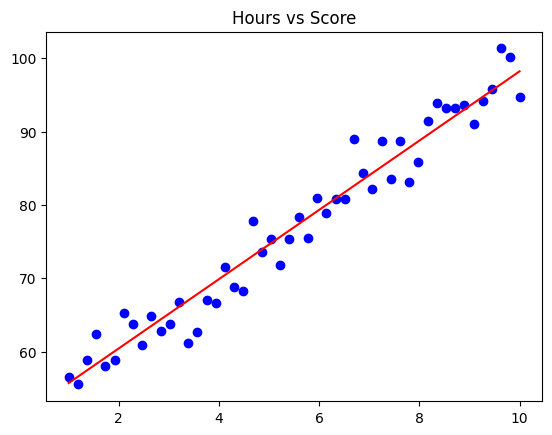

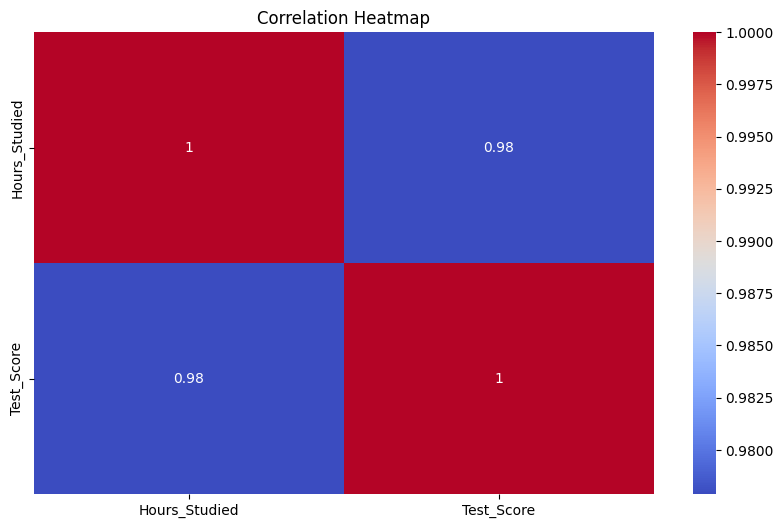

In [5]:
# 1. Load Data
df = pd.read_csv('study_data.csv')
X = df[['Hours_Studied']] 
y = df['Test_Score']      

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predict and Evaluate
predictions = model.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, predictions):.2f}")

# 5. Visualize
plt.scatter(X, y, color='blue')
plt.plot(X, model.predict(X), color='red')
plt.title('Hours vs Score')
plt.show()

df[['Test_Score', 'Hours_Studied']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


**Multiple Linear Regression**

R-squared Score: 1.00
           Coefficient
SqFt        149.059538
Bedrooms  10129.037894
Age        -505.935498


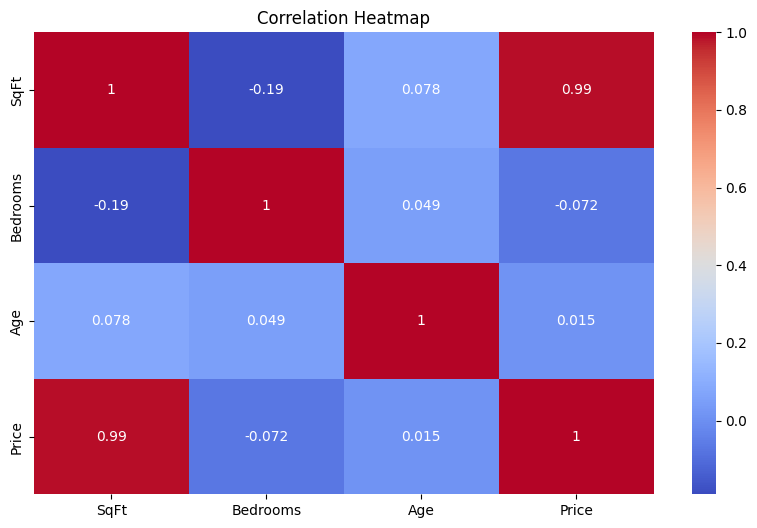

In [ ]:
from sklearn.metrics import r2_score

# Load Data
df = pd.read_csv('housing_data.csv')
X = df[['SqFt', 'Bedrooms', 'Age']] 
y = df['Price']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

# Evaluate
predictions = mlr_model.predict(X_test)
print(f"R-squared Score: {r2_score(y_test, predictions):.2f}")

# Show Coefficients
coeff_df = pd.DataFrame(mlr_model.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

#Visualize
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

# Load the housing data we created
df = pd.read_csv('housing_data.csv')
X = df[['SqFt', 'Bedrooms', 'Age']]
y = df['Price']

# Gradient Descent requires scaling (normalization)
# Otherwise, SqFt (thousands) will dominate Age (tens)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run the model step-by-step
sgd = SGDRegressor(max_iter=1, tol=None, warm_start=True, learning_rate='constant', eta0=0.01)

print(f"{'Iteration':<12} | {'SqFt Weight':<12} | {'Bedrooms Weight':<15} | {'Age Weight':<12}")
print("-" * 60)

for i in range(1, 11): 
    sgd.partial_fit(X_scaled, y)
    weights = sgd.coef_
    print(f"{i:<12} | {weights[0]:<12.2f} | {weights[1]:<15.2f} | {weights[2]:<12.2f}")

Iteration    | SqFt Weight  | Bedrooms Weight | Age Weight  
------------------------------------------------------------
1            | 56792.81     | 1406.95         | 297.07      
2            | 78651.72     | 4675.15         | -3067.14    
3            | 86658.76     | 7772.26         | -4647.06    
4            | 90118.38     | 9443.86         | -5392.98    
5            | 91298.64     | 10460.94        | -5985.21    
6            | 91939.45     | 10806.72        | -6155.35    
7            | 92406.95     | 11091.30        | -6110.21    
8            | 92448.55     | 11218.35        | -6442.07    
9            | 92389.61     | 11274.37        | -6539.79    
10           | 92478.85     | 11347.02        | -6493.96    


**Logistic Regression**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Data
df = pd.read_csv('emails.csv')
X = df['Content']
y = df['Is_Spam']

# Vectorization (Turning words into numbers)
# This creates a "vocabulary" and counts how often each word appears
vectorizer = CountVectorizer()
X_vectorized = vectorizer.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

# Train Logistic Regression
# C is the inverse of regularization strength
# Smaller C = More Regularization (Simpler model, Low Variance)
# Larger C = Less Regularization (More complex model, fits data more)
model = LogisticRegression(C=0.01, penalty='l2')
model.fit(X_train, y_train)

# Predict probabilities and apply a custom threshold
probs = model.predict_proba(X_test)[:, 1]
threshold = 0.1
predictions = (probs >= threshold).astype(int)

# 6. Evaluate
print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

Accuracy: 0.60

Confusion Matrix:
[[ 0  8]
 [ 0 12]]


In [ ]:
# Load Data
df = pd.read_csv('confusing_emails.csv')
X = df['Content']
y = df['Is_Spam']

# Vectorization (Turning words into numbers)
# This creates a "vocabulary" and counts how often each word appears
vectorizer = CountVectorizer()
X_vectorized = vectorizer.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

# Train Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict probabilities and apply a custom threshold
probs = model.predict_proba(X_test)[:, 1]
threshold = 0.2
predictions = (probs >= threshold).astype(int)

# 6. Evaluate
print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

Accuracy: 0.95

Confusion Matrix:
[[ 8  1]
 [ 0 13]]


**K-Nearest Neighbor**

C:\Users\smart fujitsu\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Scouting Results - Top 5 Most Similar Players:
     Goals_Per_Game  Successful_Dribbles  Tackles_Per_Game  Role_ID
169        0.715016             7.254711          1.193922        0
116        0.693238             7.786431          1.060148        0
37         0.743370             7.375315          1.428752        0
109        0.742310             7.815817          1.324447        0
55         0.765110             7.808593          1.170795        0


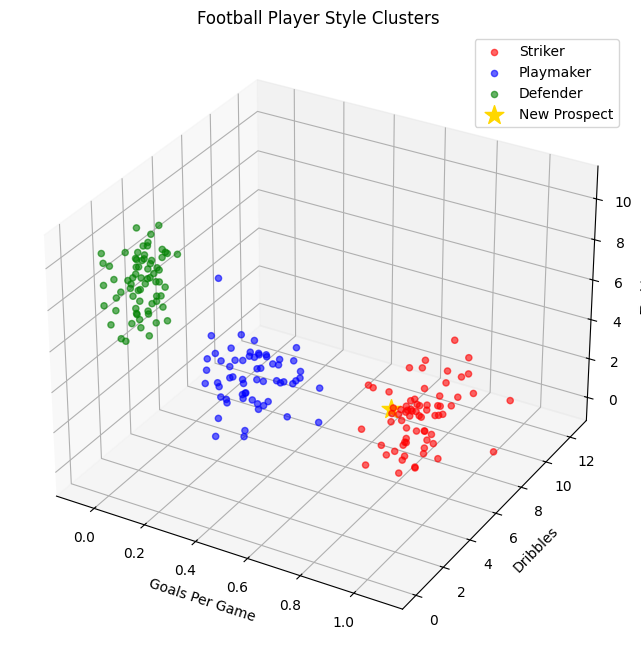

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Load and Scale
df = pd.read_csv('players.csv')
X = df.drop('Role_ID', axis=1)
y = df['Role_ID']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Train KNN
# K=5 is great for finding a small 'shortlist' of similar players
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_scaled, y)

# Scouting Exercise: Find neighbors for a new talent
# Stats: [Goals: 0.7, Dribbles: 7.5, Tackles: 1.2]
new_prospect = scaler.transform([[0.7, 7.5, 1.2]])

# Find the 5 closest neighbors (the 'Shortlist')
distances, indices = knn.kneighbors(new_prospect)

print("Scouting Results - Top 5 Most Similar Players:")
print(df.iloc[indices[0]])

# Create the figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Colors for our roles
colors = {0: 'red', 1: 'blue', 2: 'green'}
labels = {0: 'Striker', 1: 'Playmaker', 2: 'Defender'}

# Plot each group
for role in [0, 1, 2]:
    subset = df[df['Role_ID'] == role]
    ax.scatter(subset['Goals_Per_Game'], 
               subset['Successful_Dribbles'], 
               subset['Tackles_Per_Game'], 
               c=colors[role], 
               label=labels[role], 
               alpha=0.6)

# Plot the "New Prospect" we scouted earlier (Yellow Star)
ax.scatter(0.7, 7.5, 1.2, c='gold', marker='*', s=200, label='New Prospect')

ax.set_xlabel('Goals Per Game')
ax.set_ylabel('Dribbles')
ax.set_zlabel('Tackles')
ax.set_title('Football Player Style Clusters')
ax.legend()

plt.show()